In [24]:
#@title Colab Setup
# --- Colab setup ---
# In Colab there's no local database/cve.db, so fetch it from a GitHub Release asset.
# Locally (JupyterLab etc.) this cell does nothing -- the existing database/cve.db is used.
import sys
import urllib.request
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    DB_URL = "https://github.com/opendr-io/causality/releases/download/2.0/cve.db"
    db_path = Path("database/cve.db")
    db_path.parent.mkdir(parents=True, exist_ok=True)
    if not db_path.exists():
        print(f"Downloading cve.db from {DB_URL} ...")
        urllib.request.urlretrieve(DB_URL, db_path)
        print(f"Downloaded {db_path.stat().st_size:,} bytes -> {db_path}")
    else:
        print(f"{db_path} already present, skipping download")
else:
    print("Not running in Colab -- using local database/cve.db")

Not running in Colab -- using local database/cve.db


## Causality Project Notebook
CAUSALITY is an ML model making provable predictions of which CVEs will be watchlisted for widespread exploitation in order to avoid more exploitation cycles, give that time back, and live our best lives. The model has made 286 provable public predictions so far and this notebook will make it simpler to audit the evidence and verify that these predictions were made forward in time. 

The model does not use CVSS data. Unlike EPSS, it is not on a 30 day time window, because time-to-watchlisting varies between a week and a year or more. CAUSALITY is different in that it considers operator sentiment regarding exploits and target packages. Enter a query below to see a prediction rating label for a CVE issued in 2024 - 2026. Predicted CVEs will show the GitHub audit trail, for the model output files, which can be used to verify a prediction was published before it came true. The project lives here: https://github.com/opendr-io/causality

In [35]:
#@title Display Configuration
# --- Display configuration ---
# Edit these two lists to control what shows up in the "Fields to show" picker below.

# All fields available (checkbox grid always lists them in this order).

COLUMNS = [
    "year", "cve", "assigner", "published", "title", "description",
    "vendor", "product", "affected_versions", "kev", "rating", "pred_date",
    "audit_kev_date", "audit_github_timestamp", "audit_run_label",
    "audit_source_file", "audit_source_line"
]

UNIFIED_COLUMNS = [
    "cve", "published", "rating", "pred_date",
    "audit_github_timestamp", "audit_run_label",
    "audit_source_file", 
    "vendor", "product", 
    "title", "description", "audit_source_line"
]

# Subset of UNIFIED_COLUMNS that's checked (visible) by default on load. The ORDER you
# list them in here is the order they'll appear as table rows -- reorder this list to
# reorder the table. Any field not listed here still shows up (appended at the end, in
# UNIFIED_COLUMNS order) if you check its box later.
DEFAULT_VISIBLE_COLUMNS = UNIFIED_COLUMNS

# Combined row-display order: DEFAULT_VISIBLE_COLUMNS first (as ordered above), then any
# remaining UNIFIED_COLUMNS fields not covered by it.
DISPLAY_ORDER = list(DEFAULT_VISIBLE_COLUMNS) + [c for c in UNIFIED_COLUMNS if c not in DEFAULT_VISIBLE_COLUMNS]

# Row highlight color per rating label, used by the year x rating summary table below.
# Edit these hex values (or add new rating names) to change the highlighting.
RATING_COLORS = {
    "cold": "#2E75B6",
    "warm": "#FFF3B0",
    "hot": "#FFC98B",
    "fire": "#FF9E9E",
    "sunspot": "#36454F",
}
DEFAULT_ROW_COLOR = "#EEEEEE"   # any rating not listed in RATING_COLORS

#### Enter a CVE number below. 
Explanation of fields: 'rating' is the temperature potential label applied by the CAUSALITY mode:
- Ratings of 'fire' and 'hot' have high potential for widespread exploitation.
- A 'warm' rating has lower potential and 'cold' has low potential.
- The pred_date field is the date the CVE prediction was published. How do we verify that? The audit fields - github timestamp, run label, and source file, show the audit trail artifacts that prove a prediction was made before it came true.
- The vendor, product, title and description fields are from the CVE record. Not all CVEs have a title; they should have a description and a vendor / product. 

In [36]:
#@title CVE Search & Filter
import html
import math
import sqlite3
from pathlib import Path

import ipywidgets as widgets
import pandas as pd
from IPython.display import HTML, clear_output, display

DB_PATH = Path("database/cve.db")
if not DB_PATH.exists():
    raise FileNotFoundError(f"SQLite database not found: {DB_PATH.resolve()}")

BASE_CTE = """
WITH vulns AS (
    SELECT
        2024 AS year,
        p.cve AS cve,
        NULL AS assigner,
        NULL AS published,
        NULL AS title,
        p.description AS description,
        p.vendor AS vendor,
        p.product AS product,
        NULL AS affected_versions,
        NULL AS kev,
        p.predicted_label AS rating,
        pd.pred_date AS pred_date,
        a.kev_date AS audit_kev_date,
        a.github_timestamp AS audit_github_timestamp,
        a.run_label AS audit_run_label,
        a.source_file AS audit_source_file,
        a.source_line AS audit_source_line
    FROM preds2024 p
    LEFT JOIN pred_dates pd ON pd.cve = p.cve
    LEFT JOIN audit_py a ON a.cve = p.cve

    UNION ALL

    SELECT
        2025 AS year,
        p.cve AS cve,
        p.assigner AS assigner,
        p.published AS published,
        p.title AS title,
        p.description AS description,
        p.vendor AS vendor,
        p.product AS product,
        p.affected_versions AS affected_versions,
        p.kev AS kev,
        p.rating AS rating,
        pd.pred_date AS pred_date,
        a.kev_date AS audit_kev_date,
        a.github_timestamp AS audit_github_timestamp,
        a.run_label AS audit_run_label,
        a.source_file AS audit_source_file,
        a.source_line AS audit_source_line
    FROM preds2025 p
    LEFT JOIN pred_dates pd ON pd.cve = p.cve
    LEFT JOIN audit_py a ON a.cve = p.cve

    UNION ALL

    SELECT
        2026 AS year,
        p.cve AS cve,
        p.assigner AS assigner,
        p.published AS published,
        p.title AS title,
        p.description AS description,
        p.vendor AS vendor,
        p.product AS product,
        NULL AS affected_versions,
        p.kev AS kev,
        p.rating AS rating,
        pd.pred_date AS pred_date,
        a.kev_date AS audit_kev_date,
        a.github_timestamp AS audit_github_timestamp,
        a.run_label AS audit_run_label,
        a.source_file AS audit_source_file,
        a.source_line AS audit_source_line
    FROM preds2026 p
    LEFT JOIN pred_dates pd ON pd.cve = p.cve
    LEFT JOIN audit_py a ON a.cve = p.cve
)
"""

def read_scalar_list(sql, params=()):
    with sqlite3.connect(DB_PATH) as con:
        return [row[0] for row in con.execute(sql, params).fetchall()]


def build_filters():
    clauses = []
    params = []

    cve_query = txt_cve.value.strip().upper()
    if cve_query:
        if cve_query.startswith("CVE-") and len(cve_query.split("-")) == 3:
            clauses.append("UPPER(cve) = ?")
            params.append(cve_query)
        else:
            clauses.append("UPPER(cve) LIKE ?")
            params.append(f"%{cve_query}%")

    selected_ratings = [r for r, cb in rating_checks.items() if cb.value]
    if selected_ratings and len(selected_ratings) < len(rating_opts):
        placeholders = ",".join("?" for _ in selected_ratings)
        clauses.append(f"rating IN ({placeholders})")
        params.extend(selected_ratings)

    return clauses, params


def load_vulns(visible_cols, max_rows):
    selected = [col for col in visible_cols if col in UNIFIED_COLUMNS]
    if not selected:
        return pd.DataFrame(), 0

    clauses, params = build_filters()
    where_sql = " WHERE " + " AND ".join(clauses) if clauses else ""
    select_sql = ", ".join(f'"{col}"' for col in selected)
    count_sql = BASE_CTE + f"SELECT COUNT(*) FROM vulns{where_sql}"
    data_sql = BASE_CTE + f"SELECT {select_sql} FROM vulns{where_sql} ORDER BY year DESC, cve LIMIT ?"

    with sqlite3.connect(DB_PATH) as con:
        total = con.execute(count_sql, params).fetchone()[0]
        df = pd.read_sql_query(data_sql, con, params=params + [max_rows])
    return df, total


def options_from_db():
    return read_scalar_list(BASE_CTE + "SELECT DISTINCT rating FROM vulns WHERE rating IS NOT NULL ORDER BY rating")


rating_opts = options_from_db()

txt_cve = widgets.Text(
    value="",
    placeholder="CVE-2026-9198",
    description="CVE:",
    layout=widgets.Layout(width="260px"),
)
dd_max_rows = widgets.Dropdown(options=[1, 3, 5, 10, 100, 300, 1000], value=1, description="Max rows:")

rating_checks = {
    r: widgets.Checkbox(value=True, description=r, indent=False,
                        layout=widgets.Layout(width="120px"))
    for r in rating_opts
}
rating_box = widgets.VBox(
    [widgets.Label("Rating:")] + [widgets.HBox(list(rating_checks.values()))],
    layout=widgets.Layout(border="1px solid #ddd", padding="6px", margin="0 6px")
)

out = widgets.Output()

col_checks = {
    col: widgets.Checkbox(value=col in DEFAULT_VISIBLE_COLUMNS, description=col, indent=False,
                          layout=widgets.Layout(width="220px"))
    for col in UNIFIED_COLUMNS
}

cols_per_row = 4
check_rows = [
    widgets.HBox(list(col_checks.values())[i:i + cols_per_row])
    for i in range(0, len(col_checks), cols_per_row)
]
btn_all = widgets.Button(description="Select all", button_style="", layout=widgets.Layout(width="100px"))
btn_none = widgets.Button(description="Select none", button_style="", layout=widgets.Layout(width="100px"))


def on_all(b):
    for cb in col_checks.values():
        cb.value = True


def on_none(b):
    for cb in col_checks.values():
        cb.value = False


btn_all.on_click(on_all)
btn_none.on_click(on_none)

fields_box = widgets.VBox(
    [widgets.HBox([widgets.Label("Fields to show:"), btn_all, btn_none])] + check_rows,
    layout=widgets.Layout(border="1px solid #ddd", padding="6px", margin="6px 0")
)


def render_records(df, total_rows, visible_cols, max_rows=100):
    if total_rows == 0:
        return "<p><em>No matching rows.</em></p>"
    show = [c for c in visible_cols if c in df.columns]
    if not show:
        return "<p><em>No fields selected.</em></p>"
    blocks = []
    for idx, row in df.iterrows():
        label = html.escape(str(row.get("cve", f"Row {idx}")))
        fields_html = "".join(
            f'<tr>'
            # No hardcoded text color here (was color:#555, unreadable in dark mode) -- letting
            # it inherit the theme's own text color works in both light and dark, since this
            # row has no background color set either.
            f'<td style="font-weight:bold !important;white-space:nowrap !important;padding:2px 12px 2px 4px !important;'
            f'vertical-align:top !important;opacity:0.75;width:1% !important;text-align:left !important">{html.escape(col)}</td>'
            f'<td style="padding:2px 4px !important;word-break:break-word !important;text-align:left !important">{html.escape("" if pd.isna(row[col]) else str(row[col]))}</td>'
            f'</tr>'
            for col in show
        )
        blocks.append(
            f'<details open style="margin-bottom:6px;border:1px solid #888;'
            f'border-radius:4px;padding:2px 6px">'
            f'<summary style="cursor:pointer;font-weight:bold;padding:4px 2px">'
            f'{label}</summary>'
            f'<table style="border-collapse:collapse;width:100%;table-layout:auto;font-size:0.92em;text-align:left !important">'
            f'{fields_html}</table>'
            f'</details>'
        )
    note = (f'<p style="opacity:0.65"><em>Showing first {max_rows} of {total_rows:,} rows.</em></p>'
            if total_rows > max_rows else "")
    return note + "".join(blocks)


def filter_vulns(change=None):
    visible = [col for col in DISPLAY_ORDER if col_checks[col].value]
    df, total = load_vulns(visible, dd_max_rows.value)
    with out:
        clear_output(wait=True)
        print(f"{total:,} matching rows")
        display(HTML(render_records(df, total, visible, max_rows=dd_max_rows.value)))


txt_cve.observe(filter_vulns, names="value")
dd_max_rows.observe(filter_vulns, names="value")
for cb in rating_checks.values():
    cb.observe(filter_vulns, names="value")
for cb in col_checks.values():
    cb.observe(filter_vulns, names="value")

display(widgets.HBox([txt_cve, dd_max_rows]))
display(rating_box)
display(fields_box)
display(out)
filter_vulns()

Output()

In [37]:
#@title Accuracy
# For each rating label and year (2025, 2026 -- preds2024 has no kev column): the count
# of KEV=True CVEs with that label, the total count of ALL CVEs with that label, and what
# % of that year's total CVE population the label's total represents. kev is stored as
# 'True'/'False' in preds2025 but 'TRUE'/'FALSE' in preds2026, so match case-insensitively.
import sqlite3
import pandas as pd
from pathlib import Path

with sqlite3.connect(Path("database/cve.db")) as _con:
    _kev_rating_df = pd.read_sql_query(
        """
        SELECT 2025 AS year, rating, COUNT(*) AS count
        FROM preds2025 WHERE UPPER(kev) = 'TRUE' GROUP BY rating
        UNION ALL
        SELECT 2026 AS year, rating, COUNT(*) AS count
        FROM preds2026 WHERE UPPER(kev) = 'TRUE' GROUP BY rating
        """,
        _con,
    )
    _label_population_df = pd.read_sql_query(
        """
        SELECT 2025 AS year, rating, COUNT(*) AS total FROM preds2025 GROUP BY rating
        UNION ALL
        SELECT 2026 AS year, rating, COUNT(*) AS total FROM preds2026 GROUP BY rating
        """,
        _con,
    )
    _year_population_df = pd.read_sql_query(
        """
        SELECT 2025 AS year, COUNT(*) AS total FROM preds2025
        UNION ALL
        SELECT 2026 AS year, COUNT(*) AS total FROM preds2026
        """,
        _con,
    )

_kev_pivot = _kev_rating_df.pivot_table(index="rating", columns="year", values="count", fill_value=0, aggfunc="sum")
_label_pivot = _label_population_df.pivot_table(index="rating", columns="year", values="total", fill_value=0, aggfunc="sum")
_year_totals = _year_population_df.set_index("year")["total"]

# Drop the sunspot row from the displayed table entirely.
_kev_pivot = _kev_pivot.drop(index="sunspot", errors="ignore")
_label_pivot = _label_pivot.drop(index="sunspot", errors="ignore")

# Three columns per year: KEV count, total count for that rating, and what % of the
# year's total population that rating's total represents.
_kev_display = pd.DataFrame(index=_kev_pivot.index)
for _col in _kev_pivot.columns:
    _year_total = _year_totals[_col]
    _kev_display[f"{_col} kev count"] = _kev_pivot[_col].astype(int)
    _kev_display[f"{_col} total count"] = _label_pivot[_col].astype(int)
    _kev_display[f"{_col} % of year"] = (_label_pivot[_col] / _year_total * 100) if _year_total else 0.0

_count_cols = [c for c in _kev_display.columns if c.endswith("count")]
_pct_cols = [c for c in _kev_display.columns if c.endswith("% of year")]


def _highlight_kev_rows(df):
    # These pastel backgrounds stay light regardless of light/dark theme, so force a
    # dark text color on them explicitly -- otherwise dark-mode's default light text
    # sits on a light background and becomes unreadable.
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    for r in df.index:
        if r == "cold":
            styles.loc[r, :] = "background-color: #FFF9C4; color: #000000"
        else:
            styles.loc[r, :] = "background-color: #C8E6C9; color: #000000"
    return styles


(
    _kev_display.style
    .set_caption("Rating accuracy by year - ten percent of the CVE population gets most of the listed CVEs:")
    .format({c: "{:,.0f}" for c in _count_cols})
    .format({c: "{:.1f}%" for c in _pct_cols})
    .apply(_highlight_kev_rows, axis=None)
    .set_properties(**{"font-weight": "bold"})
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "18px"), ("font-weight", "bold"),
                                          ("caption-side", "top"), ("padding-bottom", "8px")]}
    ])
)

,2025 kev count,2025 total count,2025 % of year,2026 kev count,2026 total count,2026 % of year
rating,,,,,,
cold,17,27048,64.9%,5,26320,67.6%
fire,113,3191,7.7%,81,2068,5.3%
hot,32,5109,12.3%,12,1876,4.8%
warm,1,6322,15.2%,0,8683,22.3%


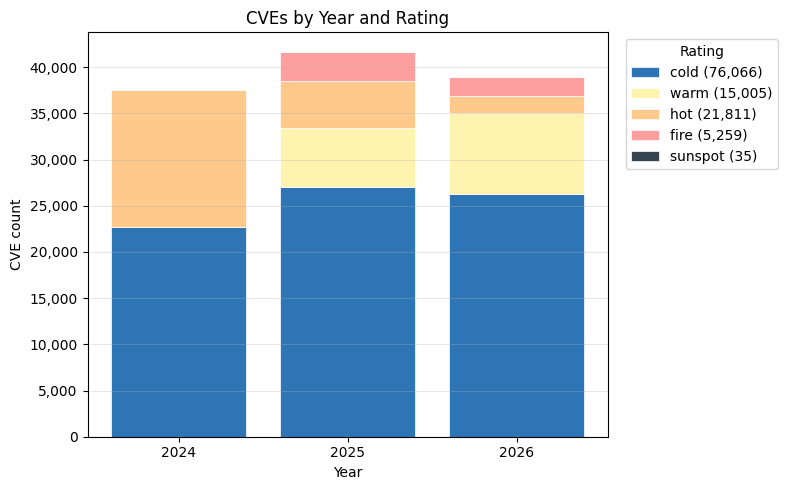

In [38]:
#@title CVEs by Year and Rating (Chart)
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

with sqlite3.connect(Path("database/cve.db")) as _con:
    _year_rating_df = pd.read_sql_query(
        """
        SELECT 2024 AS year, predicted_label AS rating, COUNT(*) AS count
        FROM preds2024 GROUP BY predicted_label
        UNION ALL
        SELECT 2025 AS year, rating, COUNT(*) AS count
        FROM preds2025 GROUP BY rating
        UNION ALL
        SELECT 2026 AS year, rating, COUNT(*) AS count
        FROM preds2026 GROUP BY rating
        """,
        _con,
    )

_pivot = _year_rating_df.pivot_table(index="rating", columns="year", values="count", fill_value=0, aggfunc="sum")

_chart_ratings = [r for r in RATING_COLORS if r in _pivot.index]
_chart_ratings += [r for r in _pivot.index if r not in _chart_ratings]
_chart_years = [c for c in _pivot.columns]

fig, ax = plt.subplots(figsize=(8, 5))
_bottom = np.zeros(len(_chart_years))
for rating in _chart_ratings:
    values = _pivot.loc[rating, _chart_years].values.astype(float)
    color = RATING_COLORS.get(rating, DEFAULT_ROW_COLOR)
    ax.bar(
        [str(y) for y in _chart_years], values, bottom=_bottom,
        color=color, edgecolor="white", linewidth=0.5,
        label=f"{rating} ({int(values.sum()):,})",
    )
    _bottom += values

ax.set_title("CVEs by Year and Rating")
ax.set_xlabel("Year")
ax.set_ylabel("CVE count")
ax.yaxis.set_major_formatter(lambda val, pos: f"{val:,.0f}")
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Rating", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [39]:
#@title Null Vendor/Product Counts by Assigner
# Count of 2026 rows with null/empty vendor or product, grouped by assigner.
import sqlite3
import pandas as pd
from pathlib import Path

with sqlite3.connect(Path("database/cve.db")) as _con:
    _null_vp_counts = pd.read_sql_query(
        """
        SELECT assigner, vendor, product, COUNT(*) AS count
        FROM preds2026
        WHERE vendor IS NULL OR TRIM(vendor) = '' OR product IS NULL OR TRIM(product) = ''
        GROUP BY assigner
        ORDER BY count DESC
        """,
        _con,
    )

_null_vp_counts

,assigner,vendor,product,count
0,mitre,,,1042
1,VulDB,,invoiceninja,414
2,snyk,,net.sourceforge.plantuml:plantuml,31
3,PostgreSQL,,pgvector,22
4,intel,,"Intel(R) Pentium(R) Processor Silver Series, I...",19
5,redhat,,migration-planner,7
6,Mautic,,mautic/core,7
7,fedora,,sipp,5
8,JFROG,,n8n,4
9,redhat-cnalr,,hackage-server,3
